# MOO/EMO 10


Pfizer is one of the leading manufacturers and distributors of pharmaceuticals worldwide. The company's direct customers are physicians, who are regularly visited by Pfizer's sales representatives. This homework focuses only on a small piece of the company's operational activities, namely the Istanbul region in Turkey. In this area, 4 company representatives operate, and the area itself is divided into 22 smaller geographical units. Each representative has their permanent office in the center of one of the regions. For each such geographical unit, data is maintained regarding sales, the number of physicians and their profiles, and based on this data, an index is calculated that reflects the "effort" associated with operational activities in that region.

Pfizer seeks to assign to its representatives areas of operational activities in such a way that, first, each region is assigned to its representative and second, the total effort associated with regions assigned to each of the representatives is similar and close to 1. The last such assignment took place many years ago and currently the company is wondering whether, following the successive changes in region indicators that have occurred over time, a better allocation of its representatives is possible. The general tasks, criteria, considered in this problem are as follows:

1. **Distance Minimization $f_1$:** To make the travel of company representatives to assigned
operational activities efficient, the solution should in some way
minimize distances between the offices of representatives and the assigned regions
to them. Data regarding distances between their representatives' offices and
each of the regions is stored in the *distance.csv* file. The f1 function should be defined
as the sum of distances between each of the representative's offices and the regions assigned to them.

2. **Minimization of Changes $f_2$:** Pfizer wanted to avoid drastic changes in the distribution of operational areas to sales representatives. They, for example, have already built good relationships with customers and it would be inadvisable to disrupt these contacts. The current assignment of regions to representatives is recorded in the *assignment.csv* file. To define a measure of "changes", the model can count how many regions changed representatives (Note: only consider regions that were not previously assigned to a given representative but in the new solution are assigned to him). Furthermore, the components of this sum could be weighted by the "effort" of regions. This is justified in the sense that for regions with low effort, a potential change of the assigned representative is not as important as in a situation where the region had high effort. The effort coefficients for regions are stored in the *effortfulness.csv* file. Finally, $f_2$ is defined as a percentage – after multiplication by 100% – of deviations from the current assignment.

Given that the current assignment is not ideal, the criteria $f_1$ and $f_2$ are to some extent contradictory to each other. Therefore, the problem is multi-criteria in nature. Three constraints are imposed here:

1. Each region must be assigned exactly one representative of the company.
2. The sum of effort for regions assigned to each representative should
be in the interval $\\left[0.9, 1.1\\right]$. Currently, the total sum of effort for all
regions equals 4, so additional normalization is not required.
3. The recommended way to represent the problem solution is a binary matrix in
which 1 means that a given employee (column) is assigned a given region
(row). The decision variables should therefore have domain $\\left\\{0,1\\right\\}$.

Implement the solution using the PULP library for Python.

> **IMPORTANT**
>
> Code written in this notebook will be checked against automatic code checker and the points will be given based on its' results, please leave the function signatures unchanged.
> As a result there are no partial points for a programing tasks

In [1]:
import pandas as pd
from pulp import *

import matplotlib.pyplot as plt

D = pd.read_csv("distance.csv", index_col=0)
P = pd.read_csv("effortfulness.csv", index_col=0)
A = pd.read_csv("assignment.csv", index_col=0)


### Task 1 (maximum points:  1)



Using the PULP library, implement the criteria `f1` and `f2`. The variable `assignment` contains a list of lists of binary variables representing the new assignment.

In [2]:
def f1(assigment: list[list[LpVariable]], D: pd.DataFrame) -> LpAffineExpression:
    res = []
    for i in range(len(D.index)):
        for j in range(len(D.columns)):
            res.append(assigment[i][j] * D.iloc[i, j])
    return lpSum(res)

In [3]:
def f2(A: pd.DataFrame, new_assigment: list[list[LpVariable]], P: pd.DataFrame) -> LpAffineExpression:
    total_effort = P['Effortfulness'].sum()
    res = []
    for i in range(len(A.index)):
        for j in range(len(A.columns)):
            if A.iloc[i, j] == 0:
                res.append(new_assigment[i][j] * P.iloc[i, 0])
    return (lpSum(res) / total_effort) * 100

In [4]:
def goal_function(model: LpProblem, assignment: list[list[LpVariable]], D: pd.DataFrame) -> None:
    model += f1(assignment, D) 

### Task 2 (maximum points:  1)



Define a constraint that each region must be assigned exactly one representative

In [5]:
def single_representative_per_region_constraint(model, assigment):
    for i in range(len(assigment)):
        model += lpSum(assigment[i]) == 1

### Task 3 (maximum points:  1)



Define a constraint that each representative is assigned regions with similar effort

In [6]:
def similar_intesivity_constraint(model, assigment, P):
    for j in range(len(A.columns)):
        res = []
        for i in range(len(assigment)):
            res.append(assigment[i][j] * P.iloc[i, 0])
        model += lpSum(res) >= 0.9
        model += lpSum(res) <= 1.1

### Task 4 (maximum points:  1)



Define the epsilon constraint. If the value `epsilon` is equal to None, the constraint should not be added.

In [7]:
def epsilon_constraint(model, assigment, P, epsilon):
    if epsilon is None:
        return
    model += f2(A, assigment, P) <= epsilon

In [8]:
def create_model(
    D: pd.DataFrame,
    A: pd.DataFrame,
    P: pd.DataFrame,
    epsilon: float | None = None,
    debug: bool = False
) -> tuple[float, float] | None:
    model = LpProblem("Pfitzer")

    assigment = [
        [LpVariable(f"A_{i}_{j}", cat=const.LpBinary) for j in range(len(A.columns))] for i in range(len(A.index))
    ]

    goal_function(model, assigment, D)
    single_representative_per_region_constraint(model, assigment)
    similar_intesivity_constraint(model, assigment, P)
    epsilon_constraint(model, assigment, P, epsilon)

    v1 = f1(assigment, D)
    v2 = f2(A, assigment, P)

    model.solve(PULP_CBC_CMD(msg=0 if not debug else 1))

    return (v1.value(), v2.value()) if model.status == LpStatusOptimal else None

### Task 5 (maximum points:  1)



Write a function that will generate all feasible solutions for this problem. Solution generation should take no more than 1 second.

In [9]:
def generate_solutions(
    D: pd.DataFrame,
    A: pd.DataFrame,
    P: pd.DataFrame,
    debug: bool = False
) -> list[tuple[float, float]]:
    raw = []
    sol = create_model(D, A, P, epsilon=None, debug=debug)
    if sol is None:
        return raw
    raw.append(sol)
    while True:
        next_eps = sol[1] - 1e-6
        if next_eps < 0:
            break
        sol = create_model(D, A, P, epsilon=next_eps, debug=debug)
        if sol is None:
            break
        raw.append(sol)
    raw.sort(key=lambda s: (s[0], s[1]))
    front = []
    best_f2 = float('inf')
    for p in raw:
        if p[1] < best_f2:
            front.append(p)
            best_f2 = p[1]
    return front

In [10]:
start = time()
repeat = 50

for _ in range(repeat):
    generate_solutions(D, A, P)

end = time()

print(f"Time: {(end - start) / repeat:.2f} seconds")

Time: 0.28 seconds


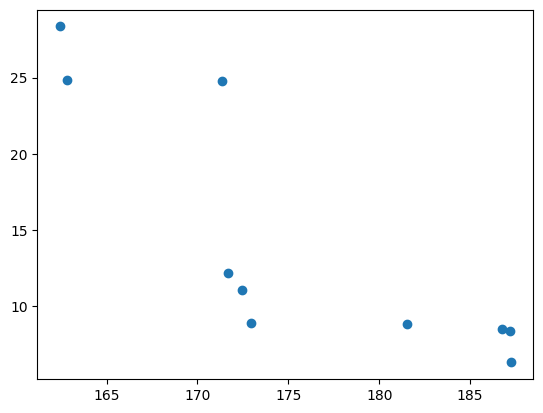

In [11]:
solutions = generate_solutions(D, A, P)

plt.scatter(*zip(*solutions))
plt.show()

## NSGA-II

In [12]:
import copy
import numpy as np

random = np.random.default_rng(0)


> IMPORTANT!
>
> When using random number generators, use only the generator defined in the random variable

In [13]:
### Solution class
class Solution:
    def __init__(self, x: list[float], f: list[float], name: str) -> None:
        self.x = x ### decision variables
        self.f = f ### evaluation vector [f1, f2]
        self.front = 0 ## additional variable storing id of non-dominated front
        self.cd = 0.0 ## additional variable storing value of crowding distance
        self.name = name ### additional variable storing name of the solution

    def __str__(self) -> str:
        return f"[{self.name} : F = ({', '.join(f'{x:.4f}' for x in self.f)})]"

### Task 6 (maximum points:  1)



You need to fill a method for evaluation of solution basing on decision variable and the formula below:
$$\min f_1\left(\bold{x}\right) = x_1^{10}l$$
$$\min f_2\left(\bold{x}\right) = \left(1 - x_1^{10}\right)l$$
$$l = 1 + \left|x_2^{10}-0.5\right|+x_3+x_4+x_5$$
, where:  
$x_1, x_2 \in \left[0, 1\right]$  
$x_3, x_4, x_5 \in \left\{0, 1\right\}$

In [14]:
def evaluate(x: list[float]) -> list[float]:
    l = 1 + abs(x[1] ** 10 - 0.5) + x[2] + x[3] + x[4]
    f1 = (x[0] ** 10) * l
    f2 = (1 - x[0] ** 10) * l
    return [f1, f2]

In [15]:
def constructInitialPopulation(N: int) -> list[Solution]:
    P = []
    for i in range(N):
        x = [j for j in range(5)]
        x[0] = random.random()
        x[1] = random.random()      
        for j in range(2,5): x[j] = random.integers(0,2).item()
        f = evaluate(x)
        P.append(Solution(x, f, str(0)+"-"+str(i)))  ### adding solution to list
        # which name consists of two parts: generation number
        # in which the solution was created and the number of solution in the population
    return P

P = constructInitialPopulation(10000)
for s in P[:10]: print(s) ### Wypisanie przykładowych rozwiązań (dla testu)

[0-0 : F = (0.0165, 1.4835)]
[0-1 : F = (0.3922, 2.7064)]
[0-2 : F = (0.1493, 3.3485)]
[0-3 : F = (0.0000, 3.2853)]
[0-4 : F = (0.1069, 2.3931)]
[0-5 : F = (0.0000, 2.4998)]
[0-6 : F = (0.0000, 3.4816)]
[0-7 : F = (0.0003, 4.4721)]
[0-8 : F = (0.1029, 4.3836)]
[0-9 : F = (0.0000, 3.4618)]



The function below plots solutions in P using a scatter plot. With large N values, you can observe how randomly generated solutions are distributed in the evaluation space. Please check, for example, with N=10000.

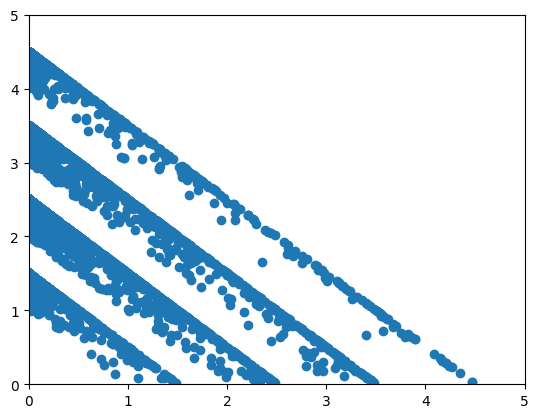

In [16]:
def plotPopul(P: list[Solution]) -> None:
    plt.figure()
    X = [s.f[0] for s in P]
    Y = [s.f[1] for s in P]
    plt.plot(X, Y, ls='', marker='o')
    plt.xlim(0, 5.0);
    plt.ylim(0, 5.0)

plotPopul(P)

### Task 7 (maximum points:  1)



Justify the obtained distribution by referring to the definition of the problem (evaluation functions)

The two objectives factor as $x_1^{10} l$ and $(1 - x_1^{10}) l$, so $f_1 + f_2 = l$. Every solution therefore lies on a diagonal of slope $-1$ in the $(f_1, f_2)$ plane. The variable $x_1$ slides a point along its diagonal; $l$ moves it between diagonals.

In $l$, the dominant component is the integer sum $x_3 + x_4 + x_5 \in \{0, 1, 2, 3\}$, which gives the four parallel bands visible at $f_1 + f_2 \approx 1, 2, 3, 4$. A faint fifth band near $4.5$ appears only when all three binaries are $1$ and $|x_2^{10} - 0.5|$ reaches its maximum of $0.5$.

The bands have thickness because $|x_2^{10} - 0.5|$ smears each one by up to half a unit. Their relative density follows $\mathrm{Bin}(3, 0.5)$ over the three fair coins — roughly $1:3:3:1$ — and the inner bands are visibly denser than the outer ones.

Within each band, solutions cluster at the corners because $x_1^{10}$ is heavily skewed toward $0$: only about $7\%$ of uniform $x_1 \in [0, 1]$ give $x_1^{10} > 0.5$. Most points land in the upper-left corner of their band ($f_1 \approx 0$); the few with $x_1 \to 1$ land in the lower-right corner ($f_2 \approx 0$). The interior of each band stays sparse.

The true Pareto front is the bottom band $l = 1$, reached when the three binaries are $0$ and $x_2^{10} = 0.5$. Everything above it is dominated. The strong corner-clustering is the imbalance that crowding distance (Task 12) is built to correct.

### Task 8 (maximum points:  1)



The function below should return a list of pairs of solution indices selected for reproduction. One offspring solution will be created from each pair. Selection should be based on a tournament of size 2. Output: list of pairs -> [ [idx11, idx12],...,[idxN1, idxN2] ]

In [17]:
def constructParents(N: int) -> list[list[int]]:
    pairs = []
    for _ in range(N):
        a = min(random.integers(0, N).item(), random.integers(0, N).item())
        b = min(random.integers(0, N).item(), random.integers(0, N).item())
        pairs.append([a, b])
    return pairs

constructParents(10)

[[1, 0],
 [7, 1],
 [0, 3],
 [1, 1],
 [1, 3],
 [0, 2],
 [0, 0],
 [4, 2],
 [3, 6],
 [1, 5]]

### Task 9 (maximum points:  1)



The function below should perform crossover of two input decision variable vectors. The procedure should implement the following scheme: the "offspring" determines the value of each variable by taking it from a random parent.

In [18]:
def getCrossed(xA: list[float], xB: list[float]) -> list[float]:
    return [xA[i] if random.random() < 0.5 else xB[i] for i in range(len(xA))]

getCrossed([0.0, 0.5, 1.0], [1.0, 0.25, 0.75])

[1.0, 0.5, 1.0]

### Task 10 (maximum points:  1)



The function below should "mutate" the input vector x (operations should be performed) on x. The procedure should take into account the probability of mutation for each decision variable. For binary variables, mutation should be implemented as complementing the variable to 1: new x[i] = 1 - x[i]. For continuous variables, you can use Gaussian mutation, i.e. add a random number from a normal distribution with standard deviation given in the method parameter "std" to the value. You should protect the procedure against potential exceedance of the updated value beyond the allowed interval [0, 1]

In [19]:
def mutate(x: list[float], prob: float, std: float) -> None:
    for i in range(2):
        if random.random() < prob:
            x[i] = x[i] + random.normal(0.0, std)
            if x[i] < 0.0:
                x[i] = 0.0
            elif x[i] > 1.0:
                x[i] = 1.0
    for i in range(2, 5):
        if random.random() < prob:
            x[i] = 1 - x[i]

for std in [0.0, 0.1, 0.2]:
    x = [0.0, 0.2, 1.0, 0.0, 0.0]
    mutate(x, 1.0, std)
    display(x)

[0.0, 0.2, 0.0, 1.0, 1.0]

[0.0, 0.15616279879999703, 0.0, 1.0, 1.0]

[0.0, 0.2090635480217356, 0.0, 1.0, 1.0]

In [20]:
def constructOffspring(P: list[Solution], parents: list[list[int]], gen: int, std: float) -> list[Solution]:
    O = []
    prob = 1.0 / 5.0
    for i in range(len(parents)):
        xO = getCrossed(P[parents[i][0]].x, P[parents[i][1]].x)
        mutate(xO, prob, std)
        O.append(Solution(xO, evaluate(xO), str(gen) + "-" + str(i)))
    return O

### Task 11 (maximum points:  1)



The function below should assign solutions to non-dominated fronts. The output should be a list of lists of indices of solutions in P assigned to the respective fronts. For example, output: [[3,4,0],[1,5],[2]] means that solutions 0, 3, 4 in P are in the first front, 1 and 5 in the second, and solution 2 in the last.

In [21]:
def getNonDominatedFronts(P: list[Solution]) -> list[list[int]]:
    n = len(P)
    F = np.asarray([s.f for s in P], dtype=float)
    le_all = (F[:, None, :] <= F[None, :, :]).all(axis=2)
    lt_any = (F[:, None, :] <  F[None, :, :]).any(axis=2)
    dominates = le_all & lt_any
    np.fill_diagonal(dominates, False)
    dom_count = dominates.sum(axis=0)
    assigned = np.zeros(n, dtype=bool)
    fronts = []
    while not assigned.all():
        mask = (dom_count == 0) & ~assigned
        if not mask.any():
            break
        idx = np.where(mask)[0]
        fronts.append(idx.tolist())
        assigned[idx] = True
        dom_count = dom_count - dominates[idx].sum(axis=0)
    return fronts

In [22]:
getNonDominatedFronts(P)

[[143,
  1271,
  1865,
  1890,
  1995,
  2481,
  3237,
  3343,
  3924,
  4315,
  4590,
  5115,
  5624,
  5950,
  6288,
  6405,
  6973,
  8244,
  8348,
  8502,
  9219,
  9802,
  9889],
 [72,
  131,
  263,
  455,
  680,
  760,
  976,
  1118,
  1129,
  1231,
  1371,
  1991,
  2380,
  2629,
  2742,
  3452,
  3496,
  3563,
  3680,
  4078,
  4805,
  4886,
  5037,
  6177,
  6461,
  7072,
  7659,
  7979,
  8071,
  8230,
  8503,
  8936,
  9645,
  9691],
 [20,
  28,
  773,
  1391,
  1404,
  1648,
  2067,
  2273,
  2692,
  3019,
  3057,
  3178,
  3185,
  3269,
  3271,
  3341,
  3605,
  4308,
  4352,
  4508,
  4526,
  4797,
  5203,
  5532,
  5777,
  5868,
  6108,
  6291,
  6321,
  6496,
  6500,
  6509,
  6923,
  7654,
  7826,
  7877,
  8129,
  8185,
  8355,
  8419,
  8518,
  8553,
  8567,
  8754,
  9152,
  9325,
  9459,
  9487,
  9570,
  9700,
  9782,
  9895],
 [88,
  94,
  237,
  469,
  481,
  561,
  919,
  1011,
  1062,
  1069,
  1357,
  1560,
  1570,
  1670,
  1986,
  2014,
  2109,
  2325,
  24

### Task 12 (maximum points:  1)



The method below should calculate the crowding distance (cd) values for solutions in P.
> **WARNING**:
>
> cd is calculated for non-dominated fronts separately; when calculating cd for solutions in one front, we "forget" about the remaining solutions. The method should return a vector of obtained cd values

In [23]:
def getCrowdingDistances(F: list[list[int]], P: list[Solution], normalize=True) -> list[float]:
    cd = [0.0] * len(P)
    M = len(P[0].f) if P else 0
    for front in F:
        size = len(front)
        if size == 0:
            continue
        if size <= 2:
            for i in front:
                cd[i] = float('inf')
            continue
        for m in range(M):
            order = sorted(front, key=lambda i: P[i].f[m])
            f_min = P[order[0]].f[m]
            f_max = P[order[-1]].f[m]
            cd[order[0]] = float('inf')
            cd[order[-1]] = float('inf')
            denom = (f_max - f_min) if normalize else 1.0
            if denom == 0:
                continue
            for k in range(1, size - 1):
                if cd[order[k]] == float('inf'):
                    continue
                cd[order[k]] += (P[order[k + 1]].f[m] - P[order[k - 1]].f[m]) / denom
    return cd

In [24]:
getCrowdingDistances(getNonDominatedFronts(P), P)

[5.0900633809156245e-05,
 0.21608372383429603,
 0.8862481253237477,
 0.2900129588317047,
 0.0006847298183060684,
 4.13518421708436e-05,
 0.009181640467420886,
 0.040868748601517055,
 0.08707027777914554,
 0.016651197754728835,
 0.0002020537608002174,
 0.000760740619538424,
 0.012397961308962459,
 0.0029306548487450556,
 0.04243054316038271,
 0.004540290344957943,
 0.028755163598662335,
 4.179467745784256e-05,
 0.0025851637497937485,
 0.0013781577686421205,
 0.027702243524898064,
 inf,
 0.149341346650968,
 0.0019849865772711135,
 0.037358398791013284,
 0.09409188466716191,
 0.0008727454121884798,
 inf,
 0.045587311135159195,
 0.10687040155863209,
 0.0041729715902026725,
 0.03576373144696488,
 0.0006181032309778276,
 0.3882017456218926,
 1.1467824565185617e-05,
 3.6241206277442475e-05,
 0.003735498284007527,
 0.023837756538838115,
 9.722418132907136e-05,
 0.03276382875120042,
 0.0047859002309548,
 0.01611951436285849,
 0.08628083924855766,
 2.0167701228601808e-05,
 0.02311371448270526,
 


The method below assigns solutions their numbers of non-dominated fronts and cd values, and also sorts solutions in the population based on these values. If useCD = False, the cd measure is not taken into account during sorting. Testing the method for useCD = True and False will allow you to observe the benefit of using the cd measure.

In [25]:
def applyScoresAndSort(P: list[Solution], useCD: bool = True) -> None:
    F = getNonDominatedFronts(P)
    CD = [0 for _ in P]
    if useCD:
        CD = getCrowdingDistances(F, P)

    for s, f in enumerate(F):
         for i in f: 
            P[i].front = s
            P[i].cd = CD[i]
   
    P.sort(key=lambda x: x.cd, reverse=True)
    P.sort(key=lambda x: x.front) # Kryterium sortowania

In [26]:
applyScoresAndSort(P)

### Task 13 (maximum points:  1)



The function below should calculate auxiliary statistics that will help justify the use of the cd measure in the calculations. The method should return the mean, maximum, minimum value of cd, as well as the standard deviation of these values in the population P. When calculating statistics, ignore boundary values (infinity) obtained by boundary values. How should these measures be interpreted?

**Mean.** Average sparsity in objective space. Should fall as the population converges onto a short segment. If it stays high or rises late in a run, the algorithm is not converging.

**Max.** Most isolated interior solution. Informative only relative to the mean — a large max with a small mean signals a lone outlier next to a clumped majority.

**Min.** Most crowded interior solution. Near-zero values flag near-duplicates; the crowding-comparison operator exists precisely to break such ties during survival selection.

**Std.** Uniformity of the spread. Small std with a non-trivial mean means evenly spaced solutions; large std means a mixture of clusters and outliers — what we get at generation $0$ or in a run that has lost diversity.

In the two driver cells above, useCD=True should keep a higher mean and lower std than useCD=False once the population has settled, since useCD=False tends to collapse onto one corner of the front.

A caveat that motivates Task 15: at generation $0$ the random scatter already produces very high CD without being anywhere near the front. CD compares variants at the same generation but says nothing about *convergence* to the front.

In [27]:
def getStatsCD(P: list[Solution]) -> tuple[float, float, float, float]:
    vals = np.array([s.cd for s in P if s.cd != float('inf')], dtype=float)
    if vals.size == 0:
        return (0.0, 0.0, 0.0, 0.0)
    return (float(vals.mean()), float(vals.max()), float(vals.min()), float(vals.std()))


The following two cells implement the NSGA-II algorithm, illustrate the constructed solutions at 5 different stages of the algorithm’s execution, and finally display the obtained statistics for CD. In the first cell, CD is not used during sorting; in the second one, it is. You should examine the code and test its behavior for different parameters (population sizes, etc.). For which variant did the algorithm perform better? (It should be the one that used the CD measure ;) )

(0.0, 0.0, 0.0, 0.0)


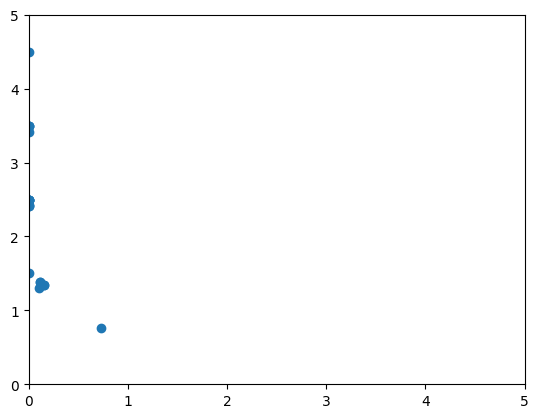

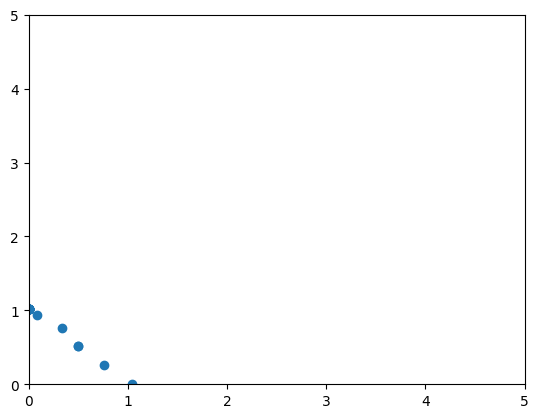

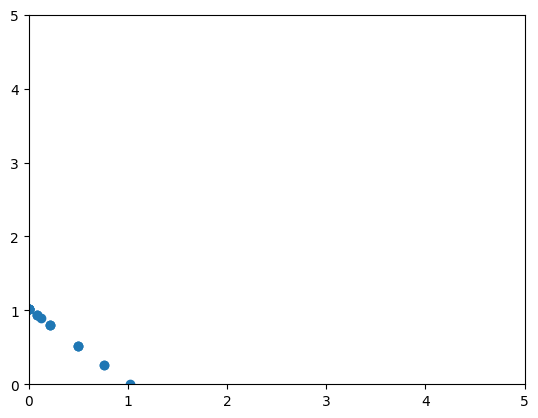

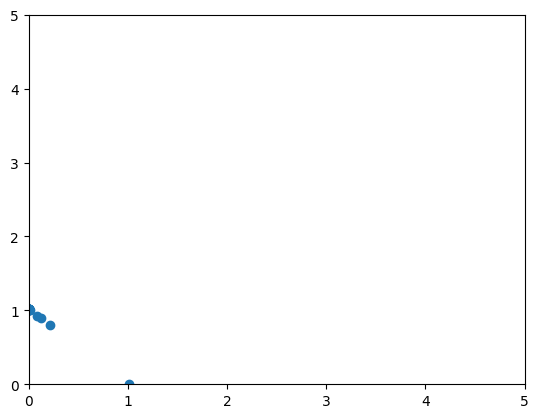

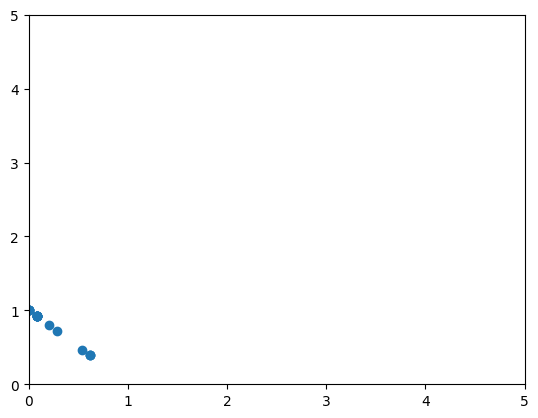

In [28]:
### Pominięcie miary CD
N = 20 # rozmiar populacji
GEN = 100 # liczba generacji/iteracji algorytmu
 
P = constructInitialPopulation(N) # utworzenie populacji początkowej
applyScoresAndSort(P, useCD = False) # posortowanie populacji wykorzystując fronty
# niezdominowane (bez miary cd; useCD = False)

for gen in range(GEN): # iteracja po kolejnych generacjach
    C = constructParents(N) # skonstruowanie identyfikatorów rodziców
    O = constructOffspring(P, C, gen + 1, 0.1) # konstrukcja potomstwa
    M = P + O # połączenie obecnej populacji z potomną
    applyScoresAndSort(M, useCD = False) # posortowanie tak połączonej populacji
    P = M[:N] # "przeżywają najlepiej przystosowani"
    if gen % (GEN / 4) == 0 or gen == GEN - 1: plotPopul(P) # co jakiś krok
        # ilustrowana jest populacja

# wypisanie statystyk
print(getStatsCD(P))

(0.22193972027279585, 0.5111878360042219, 0.0603830797594914, 0.0906706225508368)


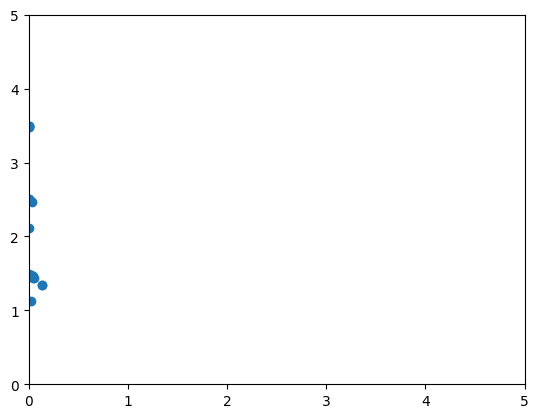

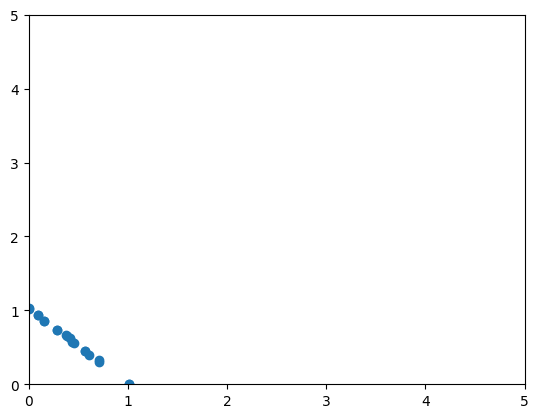

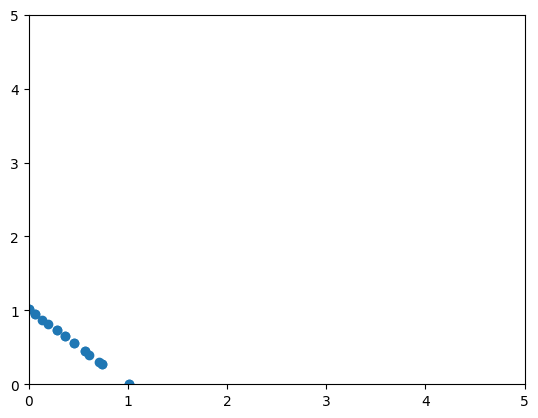

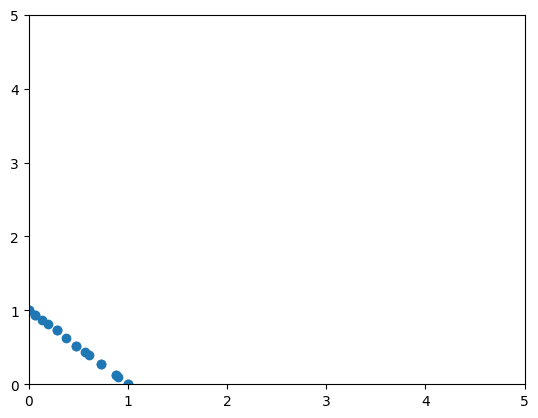

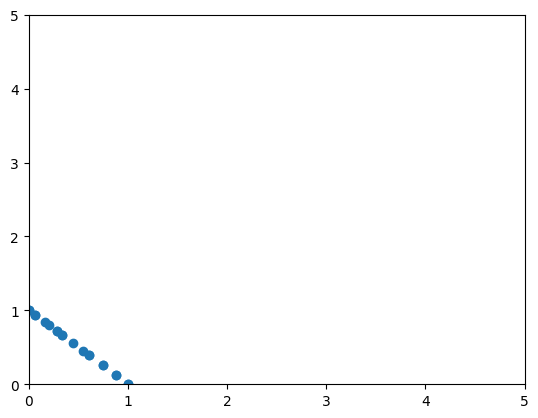

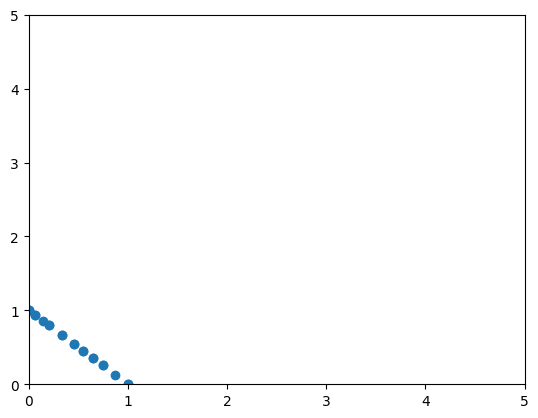

In [29]:
N = 20
GEN = 100

P = constructInitialPopulation(N)
applyScoresAndSort(P, useCD = True)

for gen in range(GEN):
    C = constructParents(N)
    O = constructOffspring(P, C, gen + 1, 0.1)
    M = P + O
    applyScoresAndSort(M, useCD = True)
    P = M[:N]
    if gen % (GEN / 5) == 0 or gen == GEN - 1: plotPopul(P)

print(getStatsCD(P))

### Task 14 (maximum points:  2)


<b>Dla chętnych: </b> algorytmy ewolucyjne są losowe. Z tego powodu jednokrotne ich uruchomienie nie jest wiarygodne. By uzyskać bardziej wiarygodny wynik, algorytm może zostać uruchomiony np. 20 razy a uzyskane statystyki uśrednione. Dodatkowo można je obliczyć dla każdej generacji (nie tylko w ostatniej) i wykreślić ich zbieżność na wykresie liniowym. Na jednym wykresie można wykreślić wyniki uzyskane przez oba warianty algorytmu - dzięki czemu różnice powinny byc lepiej widoczne. Proszę zauważyć jednak, że statystki dla cd nie są możliwie najlepszą miarą oceny jakości działania algorytmu. Na samym początku, gdy rozwiązania są silnie rozproszone, ich wartości cd powinny być bardzo wysokie, co jest w sprzeczności z założeniem, że "im większe cd tym lepiej". Aby wiarygodniej oceniać takie algorytmy, należy także wykorzystywać miary, które szacują odległość rozwiązań do frontu Pareta. Można zaproponować taką miarę i wykorzystać ją do pokazania "bliskości" populacji do tego frontu. Dopiero jednoczesne zestawienie takiej miary i miary oceniającej rozproszenie rozwiązań umożliwi lepsze porównanie algorytmów. 

### Task 15 (maximum points:  2)



**For the interested:** evolutionary algorithms are random. For this reason, a single run is not reliable. The algorithm can be run, for example, 20 times and the resulting statistics averaged. Additionally, they can be calculated for each generation (not just the last one) and their convergence plotted on a line chart. On one chart, you can plot the results obtained by both variants of the algorithm - so the differences should be more visible. However, please note that statistics for cd are not necessarily the best measure of algorithm quality. At the beginning, when solutions are highly dispersed, their cd values should be very high, which is contrary to the assumption that "the higher the cd the better". To more reliably evaluate such algorithms, measures that estimate the distance of solutions to the Pareto front should also be used. You can propose such a measure and use it to show the "proximity" of the population to that front. Only a simultaneous set of such a measure and a measure assessing the dispersion of solutions will allow for a better comparison of algorithms.

For this problem the Pareto front is known analytically: the segment from $(0, 1)$ to $(1, 0)$ on the line $f_1 + f_2 = 1$, attained when $x_3 = x_4 = x_5 = 0$ and $x_2^{10} = 0.5$. Given a solution $(f_1, f_2)$, we define `pareto_dist` as its Euclidean distance to this segment: project onto the line, clamp the projection to the segment, take the distance. Averaging over the population gives a single non-negative number that is zero exactly when every solution sits on the front.

The chart below shows three per-generation quantities, each averaged over 20 independent runs of each variant:

1. `pareto_dist` — convergence to the front (lower is better).
2. Mean of finite crowding-distance values — spread along the front (higher is better once converged).
3. Std of those CD values — uniformity of the spread (lower is better once converged).

The CD-aware variant should win on all three after a few dozen generations.

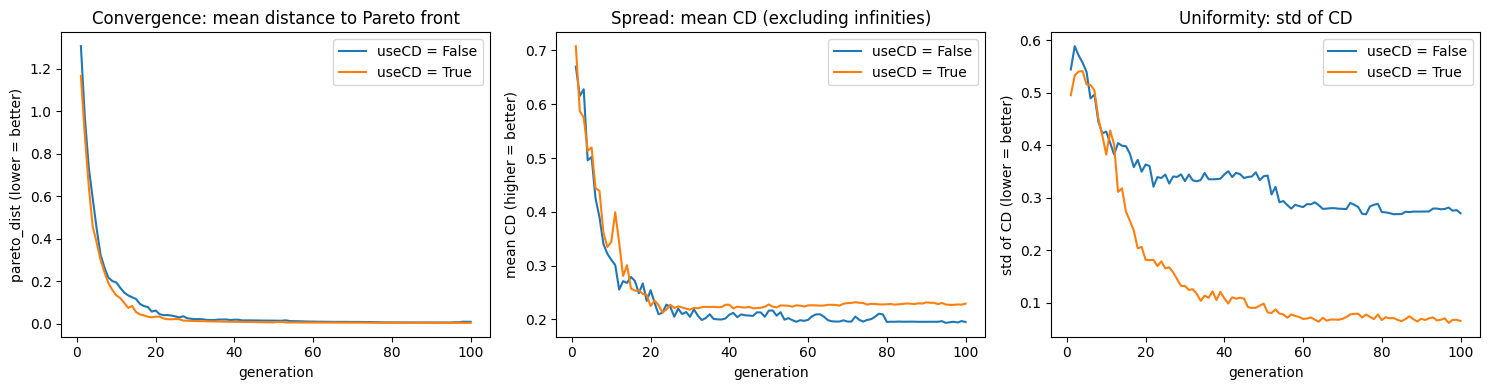

In [30]:
def paretoDistance(s: Solution) -> float:
    f1, f2 = s.f[0], s.f[1]
    t = (f1 - f2 + 1.0) / 2.0
    if t < 0.0:
        return ((f1 - 0.0) ** 2 + (f2 - 1.0) ** 2) ** 0.5
    if t > 1.0:
        return ((f1 - 1.0) ** 2 + (f2 - 0.0) ** 2) ** 0.5
    return (f1 + f2 - 1.0) / (2.0 ** 0.5)

def populationParetoDistance(P: list[Solution]) -> float:
    if not P:
        return 0.0
    return float(np.mean([paretoDistance(s) for s in P]))

def measureCDStats(P: list[Solution]) -> tuple[float, float]:
    F_meas = getNonDominatedFronts(P)
    CD_meas = getCrowdingDistances(F_meas, P)
    finite = np.array([v for v in CD_meas if v != float('inf')], dtype=float)
    if finite.size == 0:
        return 0.0, 0.0
    return float(finite.mean()), float(finite.std())

def runNSGA2(N: int, GEN: int, useCD: bool, std: float = 0.1):
    P = constructInitialPopulation(N)
    applyScoresAndSort(P, useCD=useCD)
    pd_hist, cdmean_hist, cdstd_hist = [], [], []
    for gen in range(GEN):
        C = constructParents(N)
        O = constructOffspring(P, C, gen + 1, std)
        M = P + O
        applyScoresAndSort(M, useCD=useCD)
        P = M[:N]
        pd_hist.append(populationParetoDistance(P))
        m, s_cd = measureCDStats(P)
        cdmean_hist.append(m)
        cdstd_hist.append(s_cd)
    return pd_hist, cdmean_hist, cdstd_hist

RUNS = 20
N = 20
GEN = 100

results = {False: {'pd': [], 'cdm': [], 'cds': []}, True: {'pd': [], 'cdm': [], 'cds': []}}
for r in range(RUNS):
    for useCD in (False, True):
        pd_h, cdm_h, cds_h = runNSGA2(N, GEN, useCD=useCD)
        results[useCD]['pd'].append(pd_h)
        results[useCD]['cdm'].append(cdm_h)
        results[useCD]['cds'].append(cds_h)

for useCD in (False, True):
    for k in ('pd', 'cdm', 'cds'):
        results[useCD][k] = np.array(results[useCD][k]).mean(axis=0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
gens = np.arange(1, GEN + 1)

axes[0].plot(gens, results[False]['pd'], label='useCD = False')
axes[0].plot(gens, results[True]['pd'],  label='useCD = True')
axes[0].set_title('Convergence: mean distance to Pareto front')
axes[0].set_xlabel('generation')
axes[0].set_ylabel('pareto_dist (lower = better)')
axes[0].legend()

axes[1].plot(gens, results[False]['cdm'], label='useCD = False')
axes[1].plot(gens, results[True]['cdm'],  label='useCD = True')
axes[1].set_title('Spread: mean CD (excluding infinities)')
axes[1].set_xlabel('generation')
axes[1].set_ylabel('mean CD (higher = better)')
axes[1].legend()

axes[2].plot(gens, results[False]['cds'], label='useCD = False')
axes[2].plot(gens, results[True]['cds'],  label='useCD = True')
axes[2].set_title('Uniformity: std of CD')
axes[2].set_xlabel('generation')
axes[2].set_ylabel('std of CD (lower = better)')
axes[2].legend()

plt.tight_layout()
plt.show()

*Left panel.* Both variants drop sharply as evolution flips the three binaries to $0$ and pushes $x_2^{10}$ toward $0.5$, then taper to zero. The CD-aware run sits slightly below the CD-blind one in the middle generations but they end up close — both reach the front, useCD=True a little faster.

*Middle panel.* Once solutions converge onto a short segment they are inevitably closer together than random samples in a square, so mean CD drops. The diagnostic value lies in the post-convergence gap: useCD=True stays noticeably higher because crowding-comparison prevents the population from collapsing onto a single point.

*Right panel.* useCD=True drives the std of CD down to around $0.07$ while useCD=False stalls near $0.28$. useCD=True spreads survivors evenly along the front; useCD=False alternates between dense clusters and isolated outliers. This is the textbook benefit of crowding distance — not just average spread, but a uniform approximation of the Pareto set.

What `pareto_dist` does not capture is coverage: a population concentrated at $(0, 1)$ alone would score zero, despite covering only one trade-off. The middle and right panels are what guard against that failure mode — "good convergence" requires low `pareto_dist` *and* high mean CD *and* low std of CD.

A few refinements would sharpen the comparison: shading $\pm 1$ std bands around each mean curve, replacing the perpendicular-distance metric with Inverted Generational Distance against a fine sampling of the segment, and decaying the mutation $\sigma = 0.1$ as generations advance (simulated-annealing style).